# Chapter 5: Latent Semantic Indexing (LSI)

Classical retrieval matches a query to a document by exact term overlap. If a
document uses "user" but the query says "human", there is no match, even though the
two documents may be about the same topic. Stemming and synonym lists patch some of
these gaps, but they are manual and language specific.

**Latent Semantic Indexing** (LSI) attacks the problem differently. It factorizes the
term-document matrix with a Singular Value Decomposition (SVD), keeps only the
strongest $k$ components, and projects every document into a compact space of latent
*topics*. Terms that occur in similar document contexts collapse onto the same topic
axes, so documents about the same subject sit close together even when they share no
words.

This demo reproduces the nine-document Deerwester collection from the book: it builds
the term-document matrix from raw text, computes the SVD, truncates to two topics,
projects the query "human computer interaction" into the latent space, and ranks the
documents by cosine similarity. The numbers it prints match the worked example in book
section 5.1.

## Setup

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from shared.display import print_table, display_md

## The Collection

The collection has nine documents in two clear groups: five about human-computer
interfaces (`c1` to `c5`) and four about graph theory (`m1` to `m4`). A search for
"human computer interaction" should return the `c` documents, yet most of them do not
contain those exact words. That is the vocabulary mismatch LSI has to bridge.

In [2]:
DEERWESTER = {
    "c1": "Human machine interface for Lab ABC computer applications",
    "c2": "A survey of user opinion of computer system response time",
    "c3": "The EPS user interface management system",
    "c4": "System and human system engineering testing of EPS",
    "c5": "Relation of user-perceived response time to error measurement",
    "m1": "The generation of random binary unordered trees",
    "m2": "The intersection graph of paths in trees",
    "m3": "Graph minors IV Widths of trees and well-quasi-ordering",
    "m4": "Graph minors A survey",
}
doc_ids = list(DEERWESTER)

print_table(
    [[doc_id, text] for doc_id, text in DEERWESTER.items()],
    headers=["ID", "Document"],
)

| ID   | Document                                                      |
|:-----|:--------------------------------------------------------------|
| c1   | Human machine interface for Lab ABC computer applications     |
| c2   | A survey of user opinion of computer system response time     |
| c3   | The EPS user interface management system                      |
| c4   | System and human system engineering testing of EPS            |
| c5   | Relation of user-perceived response time to error measurement |
| m1   | The generation of random binary unordered trees               |
| m2   | The intersection graph of paths in trees                      |
| m3   | Graph minors IV Widths of trees and well-quasi-ordering       |
| m4   | Graph minors A survey                                         |

## Preprocessing

We lowercase the text, split on any non-letter character (so `user-perceived` becomes
`user` and `perceived`), and drop a small stopword list. We then remove every term that
occurs in only one document: a term that appears once cannot signal a shared topic, and
dropping it keeps the matrix small. What remains is the vocabulary of the collection.

In [3]:
STOPWORDS = {"a", "an", "the", "and", "of", "for", "to", "in", "is", "it", "on", "at"}

def tokenize(text):
    """Lowercase, split on non-letters, and drop stopwords."""
    return [w for w in re.findall(r"[a-z]+", text.lower()) if w not in STOPWORDS]

tokens = {doc_id: tokenize(text) for doc_id, text in DEERWESTER.items()}

# Keep only terms that occur in the collection more than once.
term_freq = Counter(t for toks in tokens.values() for t in toks)
tokens = {d: [t for t in toks if term_freq[t] > 1] for d, toks in tokens.items()}

vocab = sorted({t for toks in tokens.values() for t in toks})

display_md(
    f"**Vocabulary: {len(vocab)} terms**\n\n"
    + ", ".join(f"`{t}`" for t in vocab)
)

**Vocabulary: 12 terms**

`computer`, `eps`, `graph`, `human`, `interface`, `minors`, `response`, `survey`, `system`, `time`, `trees`, `user`

The pruning leaves twelve terms. Words such as `machine`, `survey` (kept, it occurs in
`c2` and `m4`), `perceived`, or `well-quasi-ordering` either survive or drop out
depending on whether they recur across documents.

## The Term-Document Matrix

Each column is a document, each row a term, and each entry is the raw term frequency.
This sparse matrix $\mathbf{A}$ of size (terms $\times$ documents) is the input to the
SVD. Note that `system` appears twice in `c4`, the only entry above one.

In [4]:
n_terms, n_docs = len(vocab), len(doc_ids)
A = np.zeros((n_terms, n_docs))
for j, doc_id in enumerate(doc_ids):
    tf = Counter(tokens[doc_id])
    for i, term in enumerate(vocab):
        A[i, j] = tf.get(term, 0)

print_table(
    [[vocab[i]] + [int(A[i, j]) for j in range(n_docs)] for i in range(n_terms)],
    headers=["Term"] + doc_ids,
)

| Term      |   c1 |   c2 |   c3 |   c4 |   c5 |   m1 |   m2 |   m3 |   m4 |
|:----------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| computer  |    1 |    1 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |
| eps       |    0 |    0 |    1 |    1 |    0 |    0 |    0 |    0 |    0 |
| graph     |    0 |    0 |    0 |    0 |    0 |    0 |    1 |    1 |    1 |
| human     |    1 |    0 |    0 |    1 |    0 |    0 |    0 |    0 |    0 |
| interface |    1 |    0 |    1 |    0 |    0 |    0 |    0 |    0 |    0 |
| minors    |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    1 |    1 |
| response  |    0 |    1 |    0 |    0 |    1 |    0 |    0 |    0 |    0 |
| survey    |    0 |    1 |    0 |    0 |    0 |    0 |    0 |    0 |    1 |
| system    |    0 |    1 |    1 |    2 |    0 |    0 |    0 |    0 |    0 |
| time      |    0 |    1 |    0 |    0 |    1 |    0 |    0 |    0 |    0 |
| trees     |    0 |    0 |    0 |    0 |    0 |    1 |    1 |    1 |    0 |
| user      |    0 |    1 |    1 |    0 |    1 |    0 |    0 |    0 |    0 |

## Singular Value Decomposition

The SVD factorizes the matrix into $\mathbf{A} = \mathbf{U}\,\mathbf{S}\,\mathbf{V}^\top$.
The rows of $\mathbf{U}$ describe terms in the latent space, the diagonal of
$\mathbf{S}$ holds the singular values (the strength of each topic, in decreasing
order), and the rows of $\mathbf{V}$ describe documents. The singular values fall off
quickly, which is why a handful of topics can approximate the whole matrix.

In [5]:
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

print_table(
    [[f"sigma {i + 1}", f"{s:.2f}", "#" * int(round(s * 6))]
     for i, s in enumerate(sigma)],
    headers=["", "value", ""],
)

|         |   value |                      |
|:--------|--------:|:---------------------|
| sigma 1 |    3.34 | #################### |
| sigma 2 |    2.54 | ###############      |
| sigma 3 |    2.35 | ##############       |
| sigma 4 |    1.64 | ##########           |
| sigma 5 |    1.5  | #########            |
| sigma 6 |    1.31 | ########             |
| sigma 7 |    0.85 | #####                |
| sigma 8 |    0.56 | ###                  |
| sigma 9 |    0.36 | ##                   |

The nine singular values decrease from 3.34 to 0.36. The first two already carry most
of the structure, so truncating there loses little. The rows of $\mathbf{U}$ for
`response` and `time` come out identical, because those two terms occur in exactly the
same documents (`c2` and `c5`); the decomposition cannot tell them apart.

### Fixing the sign convention

The SVD is only unique up to sign: flipping a column of $\mathbf{U}$ together with the
matching row of $\mathbf{V}^\top$ gives an equally valid factorization. Only the
relative orientation of the axes carries meaning, and cosine similarities are
unaffected. To make the output reproducible and easy to read, we flip each component so
that its largest-magnitude term weight is positive.

In [6]:
for c in range(U.shape[1]):
    if U[np.argmax(np.abs(U[:, c])), c] < 0:
        U[:, c] *= -1
        Vt[c, :] *= -1

## Truncating to k = 2 Topics

We keep the first two components. This yields a two-dimensional topic space that we can
plot directly. $\mathbf{U}_k$ holds the term weights, $\mathbf{S}_k$ the two singular
values, and the rows of $\mathbf{V}_k$ (that is, the columns of $\mathbf{V}_k^\top$)
give each document as a 2D vector.

In [7]:
k = 2
U_k = U[:, :k]
S_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

display_md(
    f"- `U_k`: {U_k.shape[0]} terms x {U_k.shape[1]} topics\n"
    f"- `S_k`: {S_k.shape[0]} x {S_k.shape[1]} singular values "
    f"({sigma[0]:.2f}, {sigma[1]:.2f})\n"
    f"- `Vt_k`: {Vt_k.shape[0]} topics x {Vt_k.shape[1]} documents"
)

- `U_k`: 12 terms x 2 topics
- `S_k`: 2 x 2 singular values (3.34, 2.54)
- `Vt_k`: 2 topics x 9 documents

## Interpreting the Topics

A latent dimension is not a single term but a pattern of co-occurring terms. We read a
topic by listing the terms with the largest weights in the corresponding column of
$\mathbf{U}_k$.

In [8]:
for topic in range(k):
    weights = U_k[:, topic]
    order = np.argsort(-np.abs(weights))[:6]
    terms = ", ".join(f"{weights[i]:+.2f}*{vocab[i]}" for i in order)
    display_md(f"**Topic {topic + 1}:** {terms}")

**Topic 1:** +0.64*system, +0.40*user, +0.30*eps, +0.27*response, +0.27*time, +0.24*computer

**Topic 2:** +0.62*graph, +0.49*trees, +0.45*minors, +0.27*survey, -0.17*system, -0.14*eps

Topic 1 gathers the interface vocabulary (`system`, `user`, `EPS`, `response`, `time`,
`computer`); topic 2 gathers the graph vocabulary (`graph`, `trees`, `minors`,
`survey`). These are the two subjects in the collection, discovered without any labels.

## Documents in the Latent Space

An existing document folded into the latent space is simply its row of $\mathbf{V}_k$.
These are the coordinates we rank and plot. Topic 1 runs horizontally and separates the
interface documents; topic 2 runs vertically and separates the graph documents.

In [9]:
doc_coords = Vt_k.T  # one row per document, k columns

print_table(
    [[doc_ids[i], f"{doc_coords[i, 0]:+.3f}", f"{doc_coords[i, 1]:+.3f}"]
     for i in range(n_docs)],
    headers=["Doc", "Topic 1", "Topic 2"],
)

| Doc   |   Topic 1 |   Topic 2 |
|:------|----------:|----------:|
| c1    |     0.197 |    -0.056 |
| c2    |     0.606 |     0.166 |
| c3    |     0.463 |    -0.127 |
| c4    |     0.542 |    -0.232 |
| c5    |     0.279 |     0.107 |
| m1    |     0.004 |     0.193 |
| m2    |     0.015 |     0.438 |
| m3    |     0.024 |     0.615 |
| m4    |     0.082 |     0.53  |

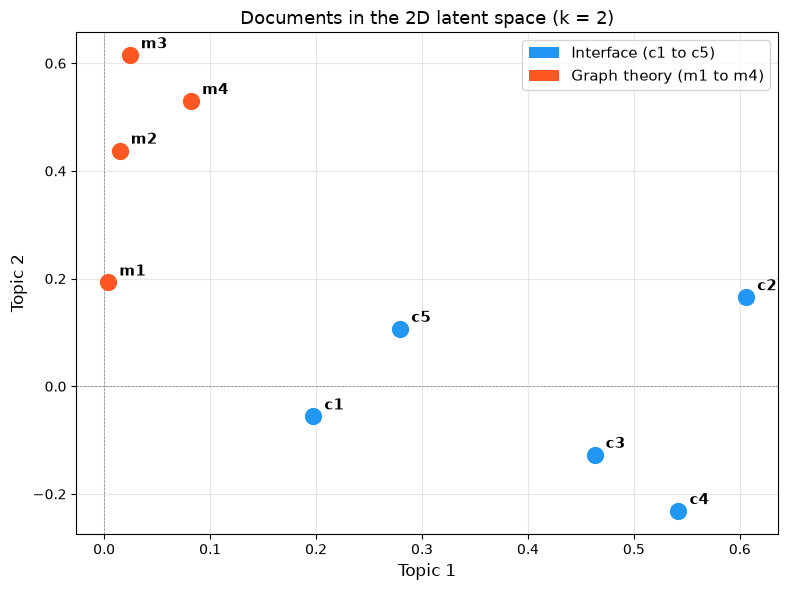

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2196F3" if d.startswith("c") else "#FF5722" for d in doc_ids]
for i, doc_id in enumerate(doc_ids):
    ax.scatter(doc_coords[i, 0], doc_coords[i, 1], c=colors[i], s=130, zorder=3)
    ax.annotate(doc_id, (doc_coords[i, 0], doc_coords[i, 1]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=11, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#2196F3", label="Interface (c1 to c5)"),
    Patch(facecolor="#FF5722", label="Graph theory (m1 to m4)"),
], loc="upper right", fontsize=11)

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Topic 1", fontsize=12)
ax.set_ylabel("Topic 2", fontsize=12)
ax.set_title("Documents in the 2D latent space (k = 2)", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The two groups fan out along different axes. The interface documents spread along topic
1 near the horizontal, and the graph documents rise along topic 2. Document `m4`
("Graph minors: A survey") leans slightly toward the interface group because it shares
the term `survey` with `c2`.

## Folding In the Query

A query is treated as a short document. We build its sparse term vector, then project it
with the folding-in formula, the same operation that produced the document coordinates:

$$\bar{\mathbf{q}}^\top = \mathbf{q}^\top\,\mathbf{U}_k\,\mathbf{S}_k^{-1}$$

Only `human` and `computer` are in the vocabulary; `interaction` is unknown and
contributes nothing.

In [11]:
def fold_in(text, U_k, S_k):
    """Project a query or new document into the k-dimensional topic space."""
    q = np.zeros(len(vocab))
    for token in tokenize(text):
        if token in vocab:
            q[vocab.index(token)] += 1
    return q @ U_k @ np.linalg.inv(S_k)

query = "human computer interaction"
q_topic = fold_in(query, U_k, S_k)

display_md(
    f'**Query:** "{query}"\n\n'
    f"Projected coordinates: ({q_topic[0]:+.3f}, {q_topic[1]:+.3f})"
)

**Query:** "human computer interaction"

Projected coordinates: (+0.138, -0.028)

The projected query lands at roughly (0.138, -0.028): almost purely on the topic 1 axis,
pointing straight at the interface documents.

## Ranking by Cosine Similarity

We rank documents by the cosine of the angle between the projected query and each
document vector. Because the query and the documents live in the same latent space, a
small angle means a shared topic, not a shared word.

In [12]:
def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

scores = sorted(
    ((doc_id, cosine(q_topic, doc_coords[i])) for i, doc_id in enumerate(doc_ids)),
    key=lambda x: -x[1],
)

print_table(
    [[rank + 1, doc_id, f"{score:+.3f}", DEERWESTER[doc_id]]
     for rank, (doc_id, score) in enumerate(scores)],
    headers=["Rank", "ID", "Cosine", "Document"],
)

|   Rank | ID   |   Cosine | Document                                                      |
|-------:|:-----|---------:|:--------------------------------------------------------------|
|      1 | c3   |    0.997 | The EPS user interface management system                      |
|      2 | c1   |    0.997 | Human machine interface for Lab ABC computer applications     |
|      3 | c4   |    0.979 | System and human system engineering testing of EPS            |
|      4 | c2   |    0.895 | A survey of user opinion of computer system response time     |
|      5 | c5   |    0.846 | Relation of user-perceived response time to error measurement |
|      6 | m4   |   -0.043 | Graph minors A survey                                         |
|      7 | m3   |   -0.157 | Graph minors IV Widths of trees and well-quasi-ordering       |
|      8 | m2   |   -0.163 | The intersection graph of paths in trees                      |
|      9 | m1   |   -0.176 | The generation of random binary unordered trees               |

Every interface document ranks above every graph document, and all four graph documents
score below zero. The ranking matches the book: c3 (0.997), c1 (0.997), c4 (0.979),
c2 (0.895), c5 (0.846).

<div style="border-left: 4px solid #C8102E; background: rgba(200, 16, 46, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#C8102E; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">LSI retrieves documents with no query terms</strong><br>
<code>c3</code> ("The EPS user interface management system") ranks at the top even though it contains neither "human" nor "computer". Its terms (<code>EPS</code>, <code>user</code>, <code>interface</code>, <code>system</code>) co-occur with the query terms across the other documents, so the SVD places it on the same topic axis. A classical exact-match model would never retrieve it.
</div>

## Seeing the Query Among the Documents

Plotting the query vector next to the documents makes the ranking visible: the interface
documents fall inside a narrow cone around the query direction, while the graph
documents sit almost at right angles to it. The shaded wedge marks the angle to the
last retrieved interface document (`c5`), the widest cosine cone that still excludes
every graph document.

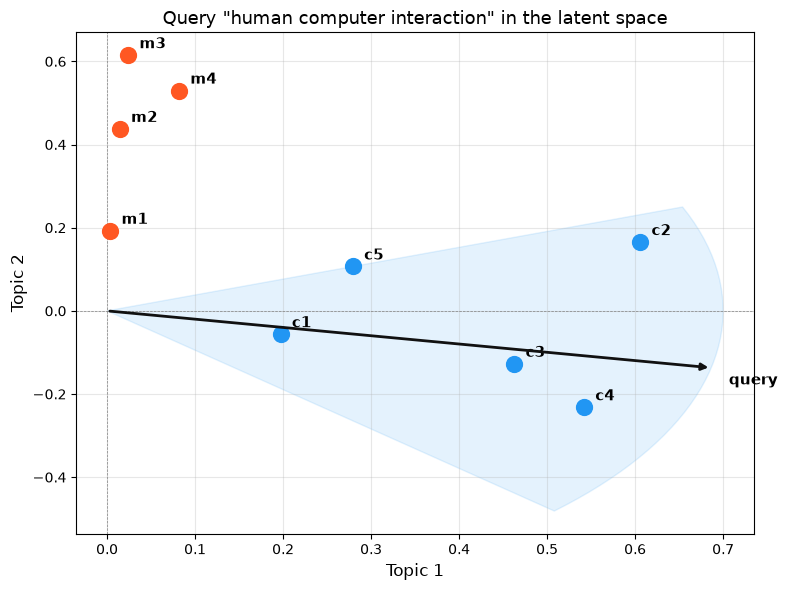

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, doc_id in enumerate(doc_ids):
    ax.scatter(doc_coords[i, 0], doc_coords[i, 1], c=colors[i], s=130, zorder=3)
    ax.annotate(doc_id, (doc_coords[i, 0], doc_coords[i, 1]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=11, fontweight="bold")

# Query direction and the cosine cone out to the last retrieved interface document.
q_angle = np.arctan2(q_topic[1], q_topic[0])
c5_angle = np.arctan2(doc_coords[doc_ids.index("c5"), 1],
                      doc_coords[doc_ids.index("c5"), 0])
half = abs(c5_angle - q_angle)
scale = 0.7
wedge = np.linspace(q_angle - half, q_angle + half, 40)
ax.fill(np.concatenate([[0], scale * np.cos(wedge)]),
        np.concatenate([[0], scale * np.sin(wedge)]),
        color="#2196F3", alpha=0.12, zorder=1)
ax.annotate("", xy=(scale * np.cos(q_angle), scale * np.sin(q_angle)), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="#111", lw=2))
ax.text(scale * np.cos(q_angle) + 0.02, scale * np.sin(q_angle) - 0.04,
        "query", fontsize=11, fontweight="bold")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Topic 1", fontsize=12)
ax.set_ylabel("Topic 2", fontsize=12)
ax.set_title('Query "human computer interaction" in the latent space', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

LSI turns the sparse term-document matrix into a dense, low-dimensional topic space with
a single SVD. Documents that share a subject line up along the same latent axes, so a
query retrieves them by topic rather than by literal word overlap. On the Deerwester
collection this pulls back all five interface documents ahead of any graph document, and
even ranks `c3` first despite it sharing no words with the query.

| Aspect | Classical (TF-IDF, BM25) | LSI |
|--------|--------------------------|-----|
| Matching | Exact term overlap | Latent topic similarity |
| Synonyms | Missed unless expanded | Captured via shared topics |
| Vectors | Sparse, high-dimensional | Dense, low-dimensional |
| Index | Inverted index (fast) | Compare all documents (slower) |
| Reading a dimension | A single term | A topic to interpret |

## Try It Yourself

The whole pipeline is a few functions. Change the inputs and re-run to explore.

**1. Rank any query.** Pass a new query string; unknown words are ignored.

In [14]:
def search(query, k=2):
    """Fold in a query and rank the collection by cosine similarity in k topics."""
    Uk, Sk, Vtk = U[:, :k], np.diag(sigma[:k]), Vt[:k, :]
    q = fold_in(query, Uk, Sk)
    coords = Vtk.T
    ranked = sorted(
        ((d, cosine(q, coords[i])) for i, d in enumerate(doc_ids)),
        key=lambda x: -x[1],
    )
    print_table(
        [[r + 1, d, f"{s:+.3f}", DEERWESTER[d]] for r, (d, s) in enumerate(ranked)],
        headers=["Rank", "ID", "Cosine", "Document"],
    )

search("graph trees survey")

|   Rank | ID   |   Cosine | Document                                                      |
|-------:|:-----|---------:|:--------------------------------------------------------------|
|      1 | m4   |    1     | Graph minors A survey                                         |
|      2 | m3   |    0.995 | Graph minors IV Widths of trees and well-quasi-ordering       |
|      3 | m2   |    0.994 | The intersection graph of paths in trees                      |
|      4 | m1   |    0.993 | The generation of random binary unordered trees               |
|      5 | c5   |    0.483 | Relation of user-perceived response time to error measurement |
|      6 | c2   |    0.395 | A survey of user opinion of computer system response time     |
|      7 | c3   |   -0.129 | The EPS user interface management system                      |
|      8 | c1   |   -0.137 | Human machine interface for Lab ABC computer applications     |
|      9 | c4   |   -0.262 | System and human system engineering testing of EPS            |

**2. Change the number of topics.** With $k = 1$ the space collapses to a single axis and
cosine can only tell two directions apart; larger $k$ retains finer distinctions but also
more noise. The table below shows how each document's score for the original query moves
as $k$ grows.

In [15]:
ks = [1, 2, 3, 4]
rows = []
for i, d in enumerate(doc_ids):
    row = [d]
    for kv in ks:
        q = fold_in(query, U[:, :kv], np.diag(sigma[:kv]))
        row.append(f"{cosine(q, Vt[:kv, :].T[i]):+.2f}")
    rows.append(row)

print_table(rows, headers=["Doc"] + [f"k={kv}" for kv in ks])

| Doc   |   k=1 |   k=2 |   k=3 |   k=4 |
|:------|------:|------:|------:|------:|
| c1    |     1 |  1    |  0.99 |  1    |
| c2    |     1 |  0.89 |  0.44 |  0.14 |
| c3    |     1 |  1    |  1    |  0.16 |
| c4    |     1 |  0.98 |  0.9  | -0.1  |
| c5    |     1 |  0.85 |  0.1  | -0.22 |
| m1    |     1 | -0.18 |  0.01 | -0.06 |
| m2    |     1 | -0.16 |  0    | -0.03 |
| m3    |     1 | -0.16 | -0    | -0.02 |
| m4    |     1 | -0.04 |  0.01 |  0.05 |

**3. Ideas to try:** add a document to `DEERWESTER` and re-run the notebook to see where
it folds in; query with a single term such as `"trees"` or `"eps"`; or raise $k$ toward
the full rank and watch the topic separation blur back into the raw term space.